In [14]:
import shap
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os 

shap.initjs()

In [2]:
# Loading the test data sets.
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(X_test.shape, y_test.shape)

(79, 41) (79,)


In [ ]:
# Loading the trained models.
log_model = joblib.load('../models/logistic_regression.pkl')
tree_model = joblib.load('../models/decision_tree.pkl')
rf_model = joblib.load('../models/random_forest.pkl')
gb_model = joblib.load('../models/gradient_boosting.pkl')
svm_model = joblib.load('../models/support_vector_machine.pkl')

print("Models loaded successfully")

Models loaded successfully


## Creating SHAP Explainers

In [6]:
# Efficient explainers
explainer_log = shap.Explainer(log_model, X_test)
explainer_tree = shap.TreeExplainer(tree_model)
explainer_rf = shap.TreeExplainer(rf_model)
explainer_gb = shap.TreeExplainer(gb_model)

# SVM (slow → use sample)
X_sample = X_test.sample(50, random_state=42)
explainer_svm = shap.KernelExplainer(svm_model.predict, X_sample)

In [7]:
# Compute SHAP values

shap_values_log = explainer_log(X_test)
shap_values_rf = explainer_rf.shap_values(X_test)
shap_values_gb = explainer_gb.shap_values(X_test)

# SVM (sample only)
shap_values_svm = explainer_svm.shap_values(X_sample)

  0%|          | 0/50 [00:00<?, ?it/s]

## Global Feature(Random forest)

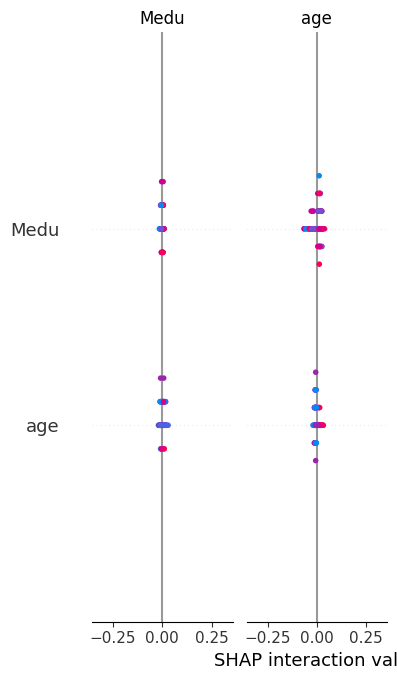

In [8]:
shap.summary_plot(shap_values_rf, X_test)

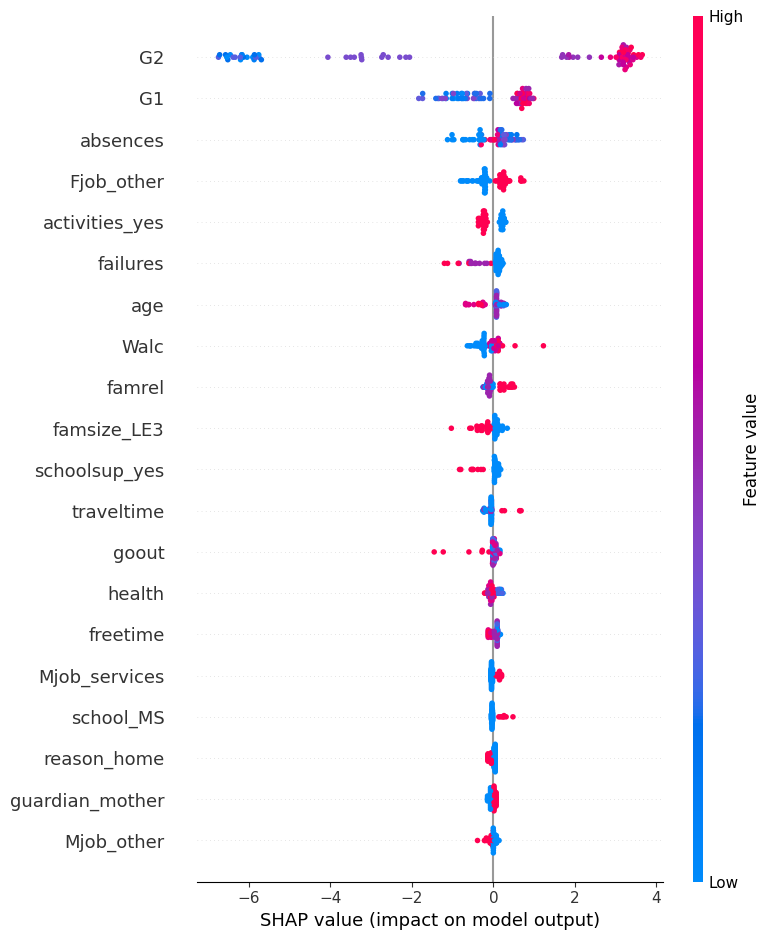

In [9]:
shap.summary_plot(shap_values_gb, X_test)

## Feature importance Bar plot.

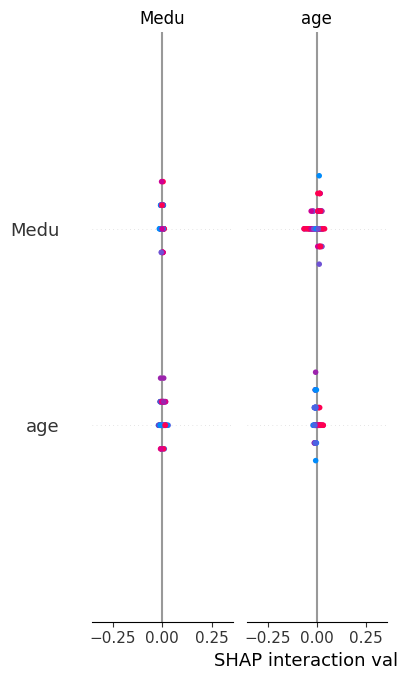

In [10]:
shap.summary_plot(shap_values_rf, X_test, plot_type="bar")

## Individual prediction (Waterfall plot)

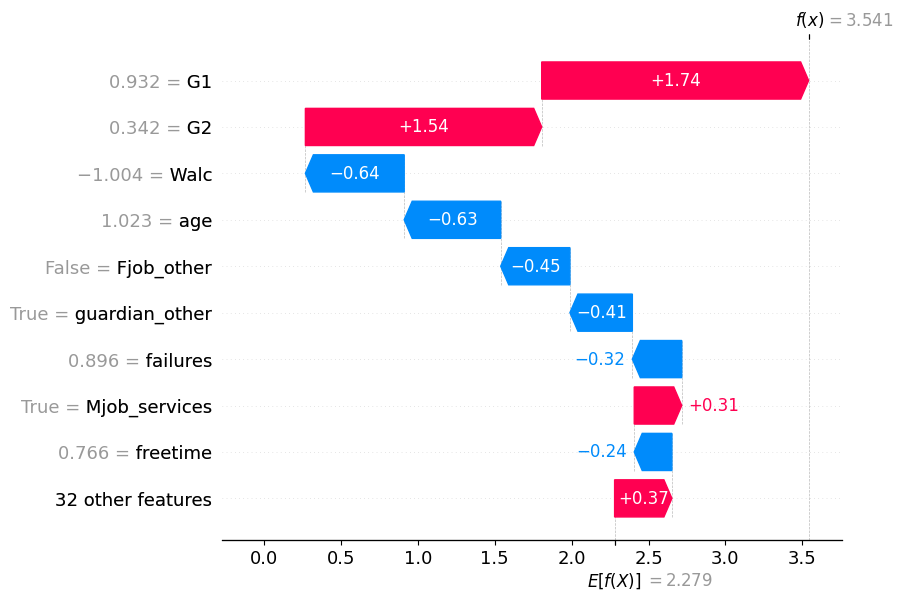

In [11]:
index = 0
shap.plots.waterfall(shap_values_log[index])

## Force Plot

In [12]:
shap.force_plot(
    explainer_log.expected_value,
    shap_values_log.values[0],
    X_test.iloc[0]
)

In [15]:
save_path = "../evaluation/shap_comparison"
os.makedirs(save_path, exist_ok=True)

shap.summary_plot(shap_values_rf, X_test, show=False)
plt.savefig(os.path.join(save_path, "rf_shap_summary.png"), bbox_inches="tight")
plt.close()